<a href="https://colab.research.google.com/github/danna0723/sistema_clasificacion_residuos/blob/main/Reciclaje_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics opencv-python kagglehub tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.0 MB/s eta 0:00:00


# Librerias

Carga todas las librerías necesarias para:

-Manejo de archivos (os, shutil)

-Lectura de datos (json)

-Procesamiento de imágenes (cv2)

-Manipulación de datos (numpy, pandas)

-Visualización (matplotlib)

-Entrenamiento del modelo YOLO

In [ ]:
import os
import json
import cv2
import shutil
import random
import numpy as np
from tqdm import tqdm
from collections import defaultdict

import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

model = YOLO("runs/detect/train/weights/best.pt")

# Mapeo de clases

Convierte las 60 clases originales del dataset TACO en 5 clases generales:

-plástico : 0

-vidrio :1

-papel : 2

-cartón: 3

-metal : 4

In [ ]:
def map_category(category_id):

    plastic = {4,5,7,21,24,27,29,36,37,38,39,40,41,42,43,44,45,47,48,49,54,55,57}
    glass = {6,9,23,26}
    paper = {20,30,31,32,33,34,35,56}
    cardboard = {13,14,15,16,17,18,19}
    metal = {0,2,8,10,11,12,28,50,52}

    if category_id in plastic:
        return 0
    elif category_id in glass:
        return 1
    elif category_id in paper:
        return 2
    elif category_id in cardboard:
        return 3
    elif category_id in metal:
        return 4
    else:
        return None

class_names = ["plastico", "vidrio", "papel", "carton", "metal"]


# Carga dataset

*Descarga el dataset desde Kaggle

*Carga imágenes y anotaciones

*Lee el archivo annotations.json

In [ ]:
path = kagglehub.dataset_download("kneroma/tacotrashdataset")
print("Ruta:", path)

dataset_path = path
images_path = os.path.join(dataset_path, "data")
annotations_path = os.path.join(dataset_path, "data", "annotations.json")

with open(annotations_path, "r") as f:
    data = json.load(f)

images = {img["id"]: img for img in data["images"]}
annotations = data["annotations"]


Using Colab cache for faster access to the 'tacotrashdataset' dataset.
Ruta: /kaggle/input/tacotrashdataset


# agrupar anotaciones

In [ ]:
img_to_anns = {}
for ann in annotations:
    img_to_anns.setdefault(ann["image_id"], []).append(ann)


# filtrar imagenes validas

Elimina imágenes que no tengan clases válidas según el mapeo, solo se conservan imágenes útiles para el entrenamiento.

In [ ]:

filtered_img_to_anns = {}

for img_id, anns in img_to_anns.items():
    valid_anns = [ann for ann in anns if map_category(ann["category_id"]) is not None]
    if len(valid_anns) > 0:
        filtered_img_to_anns[img_id] = valid_anns

print("Imágenes útiles:", len(filtered_img_to_anns))


Imágenes útiles: 1443


# Balanceo de clases

En esta parte, se aumenta la presencia de clases minoritarias duplicando imágenes con clases poco frecuentes, asi se evita que el modelo se sesgue

In [ ]:

class_count = defaultdict(int)

for anns in filtered_img_to_anns.values():
    for ann in anns:
        cls = map_category(ann["category_id"])
        class_count[cls] += 1

print("Distribución original:", dict(class_count))

max_count = max(class_count.values())

balanced_ids = []

for img_id, anns in filtered_img_to_anns.items():

    img_classes = set(map_category(a["category_id"]) for a in anns)

    weight = max([max_count // (class_count[c] + 1) for c in img_classes])
    weight = min(max(weight, 1), 3)

    for _ in range(weight):
        balanced_ids.append(img_id)

random.shuffle(balanced_ids)

print("Total balanceado:", len(balanced_ids))


Distribución original: {1: 254, 3: 251, 0: 2224, 4: 550, 2: 246}
Total balanceado: 2711


# Split Train

Se divide el dataset en:

80% entrenamiento

20% validación

Evitando asi la fuga de datos

In [ ]:

unique_ids = list(filtered_img_to_anns.keys())
random.shuffle(unique_ids)

split_idx = int(0.8 * len(unique_ids))
train_ids = set(unique_ids[:split_idx])
val_ids = set(unique_ids[split_idx:])


# Crear dataset Yolo

Aqui se crea la estructura estándar que YOLO necesita:

-imágenes

-etiquetas (labels)

In [ ]:

base_dir = "yolo_dataset"

for s in ["train", "val"]:
    os.makedirs(f"{base_dir}/images/{s}", exist_ok=True)
    os.makedirs(f"{base_dir}/labels/{s}", exist_ok=True)

for img_id in tqdm(balanced_ids):

    anns = filtered_img_to_anns[img_id]
    img_info = images[img_id]

    img_path = os.path.join(images_path, img_info["file_name"])
    if not os.path.exists(img_path):
        continue

    img = cv2.imread(img_path)
    if img is None:
        continue

    h, w = img.shape[:2]

    split = "train" if img_id in train_ids else "val"

    img_name = f"{img_id}_{random.randint(0,99999)}.jpg"
    label_name = img_name.replace(".jpg", ".txt")

    shutil.copy(img_path, f"{base_dir}/images/{split}/{img_name}")

    with open(f"{base_dir}/labels/{split}/{label_name}", "w") as f:
        for ann in anns:
            cls = map_category(ann["category_id"])
            if cls is None:
                continue

            x, y, bw, bh = ann["bbox"]

            x_center = (x + bw/2) / w
            y_center = (y + bh/2) / h
            bw /= w
            bh /= h

            f.write(f"{cls} {x_center} {y_center} {bw} {bh}\n")



100%|██████████| 2711/2711 [03:18<00:00, 13.68it/s]


# Data Yaml

En esta parte se define configuración del dataset:

-ruta

-train / val

-clases

In [ ]:

with open("data.yaml", "w") as f:
    f.write(f"""
path: {base_dir}
train: images/train
val: images/val

names:
  0: plastico
  1: vidrio
  2: papel
  3: carton
  4: metal
""")


# Modelo YOLO

Se entrena el modelo con:

-60 épocas

-tamaño 640x640

-batch 16

-optimizador AdamW

Esto incluye las siguientes mejoras:

-Mosaic

-MixUp

-Cosine LR

-Early stopping

In [ ]:
model = YOLO("runs/detect/train/weights/last.pt")


model.train(
    data="data.yaml",
    epochs=60,
    imgsz=640,
    batch=16,
    optimizer="AdamW",
    lr0=0.001,
    cos_lr=True,
    patience=20,
    augment=True,
    mosaic=1.0,
    mixup=0.2,
    close_mosaic=10,
    workers=8,
    plots=True,
    resume=True
)


Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=runs/detect/train/weights/last.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=2

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x780b9855e450>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

# Matriz de confusion

Aqui se evalúa el modelo comparando la clase real vs predicha, tambien muestra errores por clase:

La matriz nos deja ver el siguiente rendimiento por Clase (Aciertos):

Vidrio (95%): Es la clase que el modelo identifica con mayor precisión.

Plástico (90%): Tiene un desempeño muy alto, siendo la segunda clase mejor clasificada.

Metal (81%): Presenta un buen nivel de reconocimiento.

Papel (80%): Tiene un desempeño sólido, aunque con algunas confusiones específicas.

Cartón (68%): Es la clase con menor desempeño, lo que indica que es el material que más dificultad le genera al modelo.

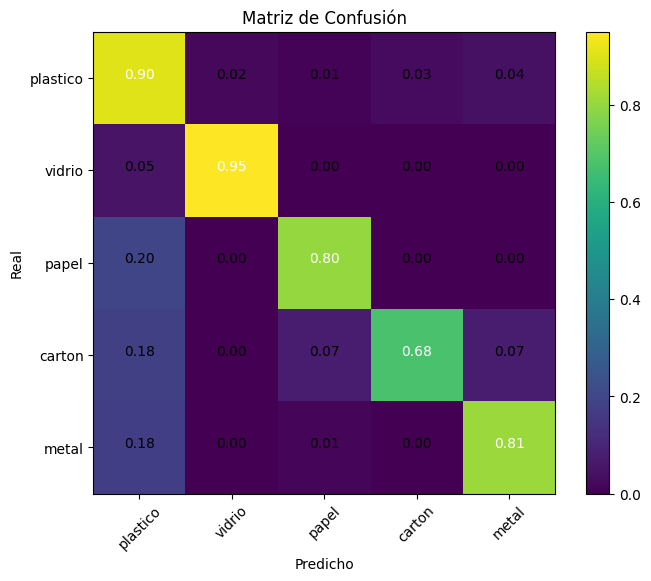

In [ ]:
best_model = YOLO("runs/detect/train/weights/best.pt")

val_images_path = f"{base_dir}/images/val"
val_labels_path = f"{base_dir}/labels/val"

image_files = os.listdir(val_images_path)

num_classes = len(class_names)
conf_matrix = np.zeros((num_classes, num_classes), dtype=int)

for img_name in image_files:

    img_path = os.path.join(val_images_path, img_name)
    label_path = os.path.join(val_labels_path, img_name.replace(".jpg", ".txt"))

    real_classes = []
    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                real_classes.append(int(line.split()[0]))

    if not real_classes:
        continue

    real_class = max(set(real_classes), key=real_classes.count)

    result = best_model.predict(img_path, conf=0.25, verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        continue

    preds = result.boxes.cls.cpu().numpy().astype(int)
    pred_class = max(set(preds), key=list(preds).count)

    conf_matrix[real_class][pred_class] += 1

# NORMALIZAR
conf_matrix_norm = conf_matrix.astype(float) / (conf_matrix.sum(axis=1, keepdims=True) + 1e-6)

plt.figure(figsize=(8,6))
plt.imshow(conf_matrix_norm)
plt.title("Matriz de Confusión")
plt.colorbar()

plt.xticks(range(num_classes), class_names, rotation=45)
plt.yticks(range(num_classes), class_names)

for i in range(num_classes):
    for j in range(num_classes):
        val = conf_matrix_norm[i, j]
        plt.text(j, i, f"{val:.2f}",
                 ha="center",
                 color="white" if val > 0.3 else "black")

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.show()


# visualizacion de predicciones
Los resultados muestran como el modelo es capaz de identificar correctamente objetos en condiciones variadas de iluminación, escala o fondo. No
obstante, en algunos casos el modelo presenta dificultades para detectar objetos pequeños o parcialmente visibles, así como para diferenciar entre clases visualmente similares.

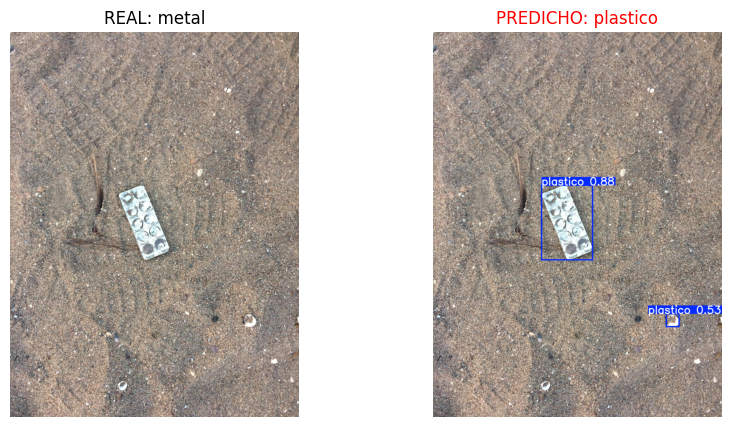

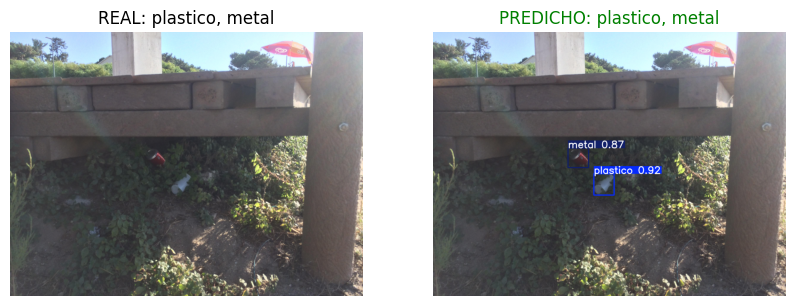

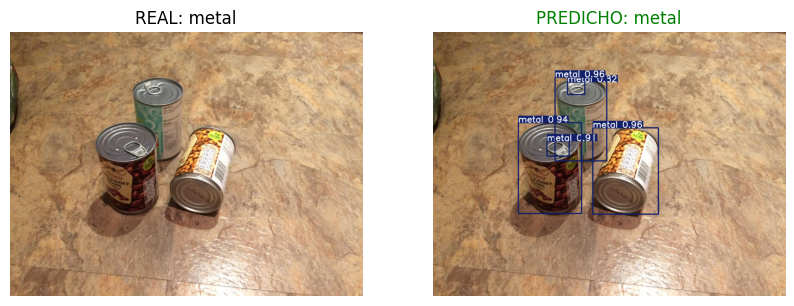

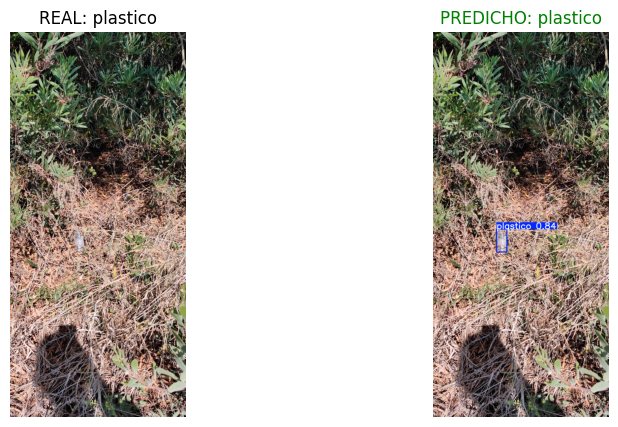

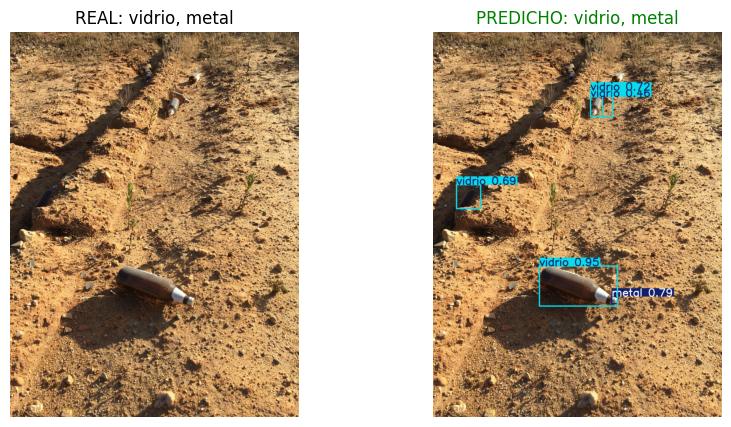

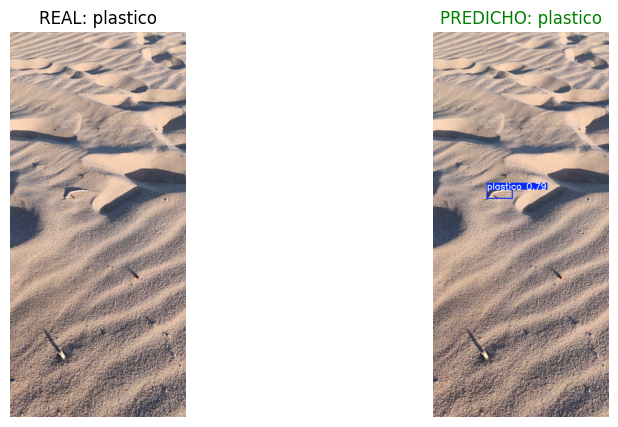

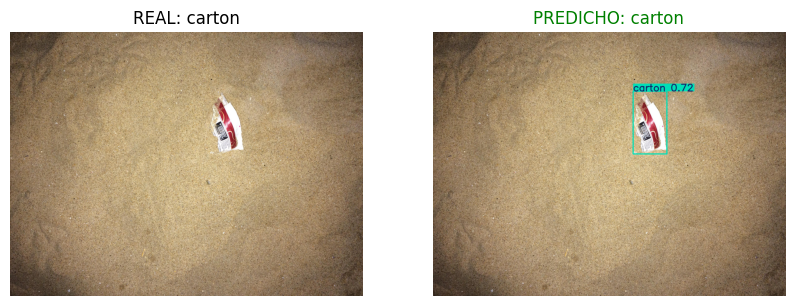

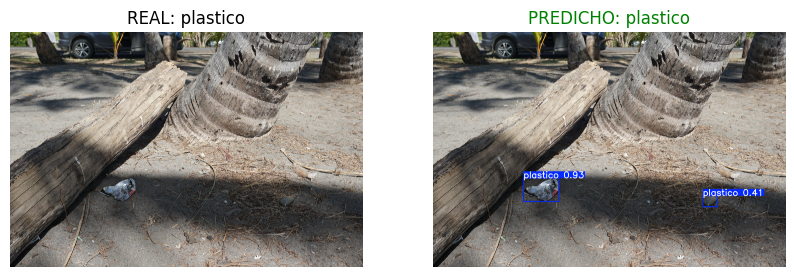

In [ ]:
samples_shown = 0
max_samples = 8

random.shuffle(image_files)

for img_name in image_files:

    if samples_shown >= max_samples:
        break

    img_path = os.path.join(val_images_path, img_name)
    label_path = os.path.join(val_labels_path, img_name.replace(".jpg", ".txt"))

    # CLASES REALES

    real_classes = []

    if os.path.exists(label_path):
        with open(label_path) as f:
            for line in f:
                real_classes.append(int(line.split()[0]))

    if not real_classes:
        continue

    real_classes_unique = sorted(set(real_classes))
    real_labels = [class_names[c] for c in real_classes_unique]
    real_text = ", ".join(real_labels)

    # PREDICCIÓN

    result = best_model.predict(img_path, conf=0.25, verbose=False)[0]

    if result.boxes is None or len(result.boxes) == 0:
        continue

    preds = result.boxes.cls.cpu().numpy().astype(int)

    pred_classes_unique = sorted(set(preds))
    pred_labels = [class_names[c] for c in pred_classes_unique]
    pred_text = ", ".join(pred_labels)

    # COMPARACIÓN

    correct = set(real_classes_unique) == set(pred_classes_unique)
    color = "green" if correct else "red"


    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    pred_img = result.plot()
    pred_img = cv2.cvtColor(pred_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,5))

    # REAL
    plt.subplot(1,2,1)
    plt.imshow(img_rgb)
    plt.title(f"REAL: {real_text}")
    plt.axis("off")

    # PREDICCIÓN
    plt.subplot(1,2,2)
    plt.imshow(pred_img)
    plt.title(f"PREDICHO: {pred_text}", color=color)
    plt.axis("off")

    plt.show()

    samples_shown += 1